In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ysy_plot_utils as ypu
import pandas as pd
import os
from scipy.signal import savgol_filter

plt.rcParams.update(ypu.ysy_settings())
ypu.liuyin_color_theme()

In [2]:
# 文件夹路径
folder = 'data'

# 存储结果的字典
rise_data = {}  # 上升数据，键是电流（int），值是DataFrame
fall_data = {}  # 下降数据，键是电流（int），值是DataFrame

# 遍历0A到8A
for current_1 in range(9):
    # 构造文件名
    rise_filename = f"{current_1}A上升.xls"
    fall_filename = f"{current_1}A下降.xls"

    # 构造完整路径
    rise_path = os.path.join(folder, rise_filename)
    fall_path = os.path.join(folder, fall_filename)

    # 读取文件
    rise_df = pd.read_csv(rise_path, encoding='latin1', sep='\t', skiprows=2, usecols=[0, 1], names=['R(V)', 'T(K)'])
    fall_df = pd.read_csv(fall_path, encoding='latin1', sep='\t', skiprows=2, usecols=[0, 1], names=['R(V)', 'T(K)'])

    # 存入字典
    rise_data[current_1] = rise_df
    fall_data[current_1] = fall_df

In [3]:
# 新建字典存放跃变区间数据
rise_focus_data = {}
fall_focus_data = {}

# 筛选数据区间并存储
for current in range(9):
    rise_df = rise_data[current]
    fall_df = fall_data[current]
    
    # 条件筛选
    rise_focus_data[current] = rise_df[(rise_df['T(K)'] >= 90) & (rise_df['T(K)'] <= 98)]
    fall_focus_data[current] = fall_df[(fall_df['T(K)'] >= 81) & (fall_df['T(K)'] <= 90)]


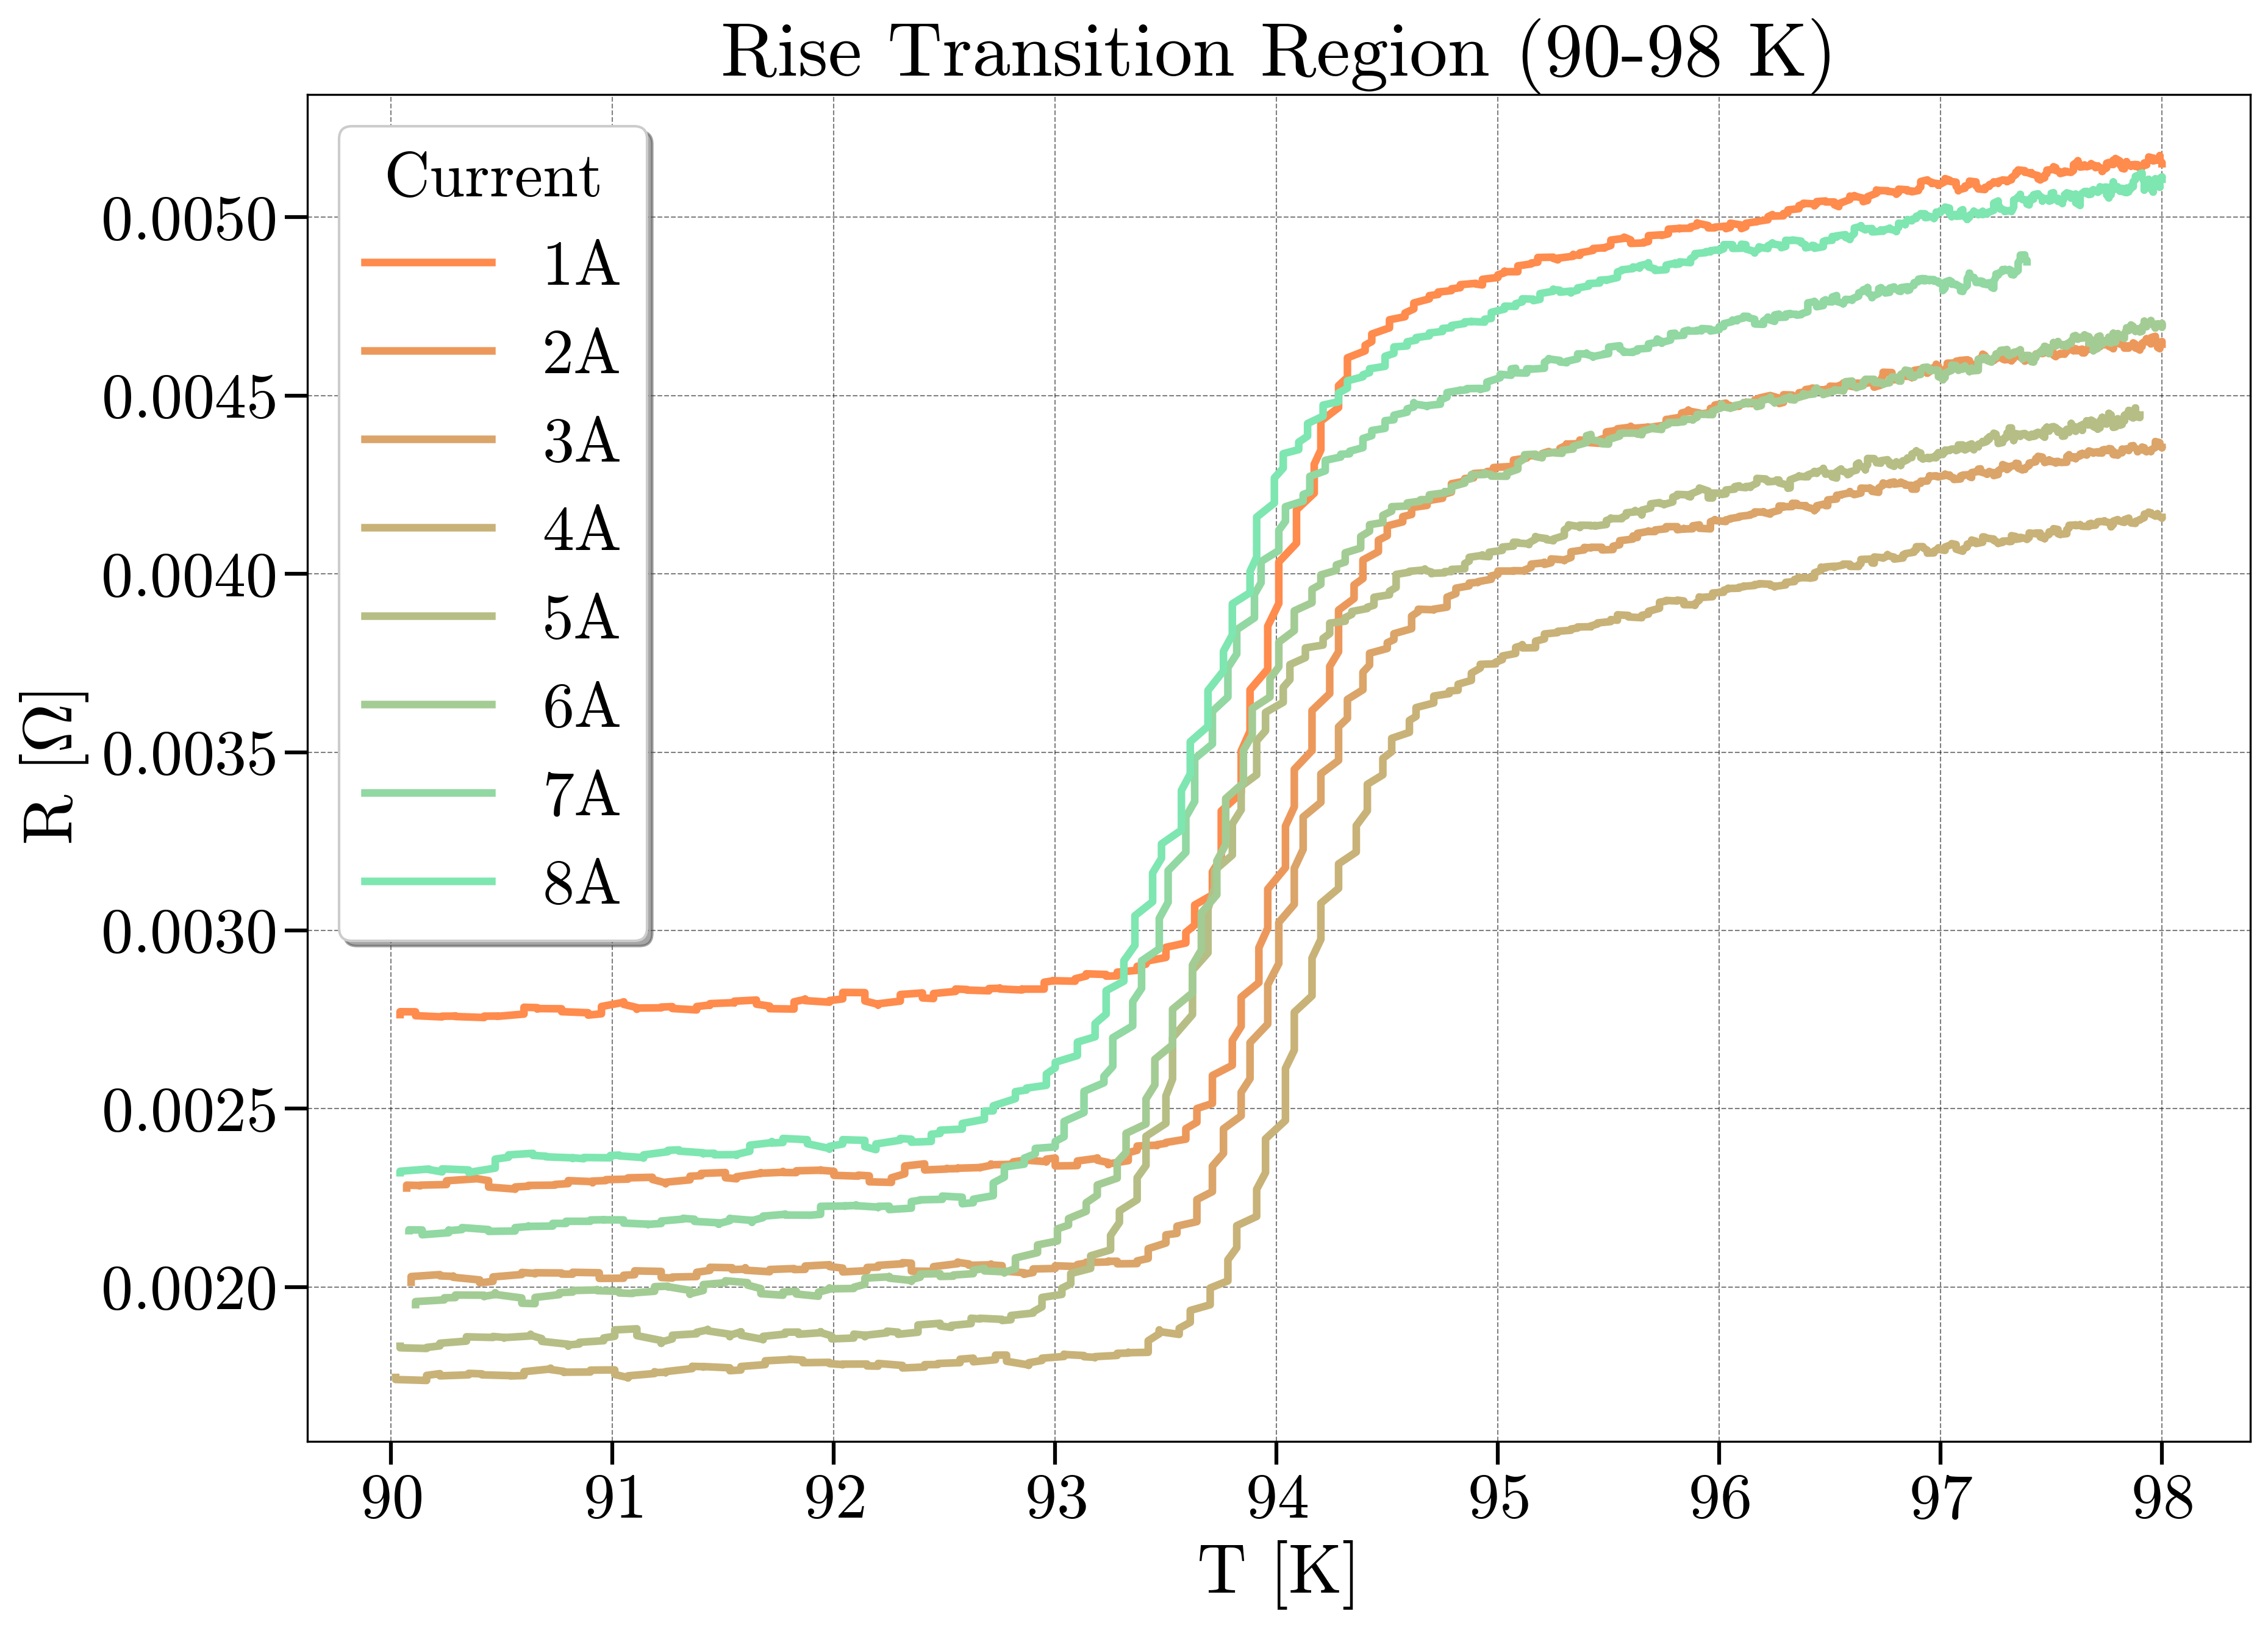

In [4]:
# 绘图：Rise（跃变区）
plt.figure()
for current, df in rise_focus_data.items():
    if current == 0:
        continue
    plt.plot(df['T(K)'].values, df['R(V)'].values/0.01, label=f'{current}A')
plt.xlabel('T [K]')
plt.ylabel('R [$\Omega$]')
plt.title('Rise Transition Region (90-98 K)')
plt.legend(title='Current')
plt.tight_layout()
plt.show()

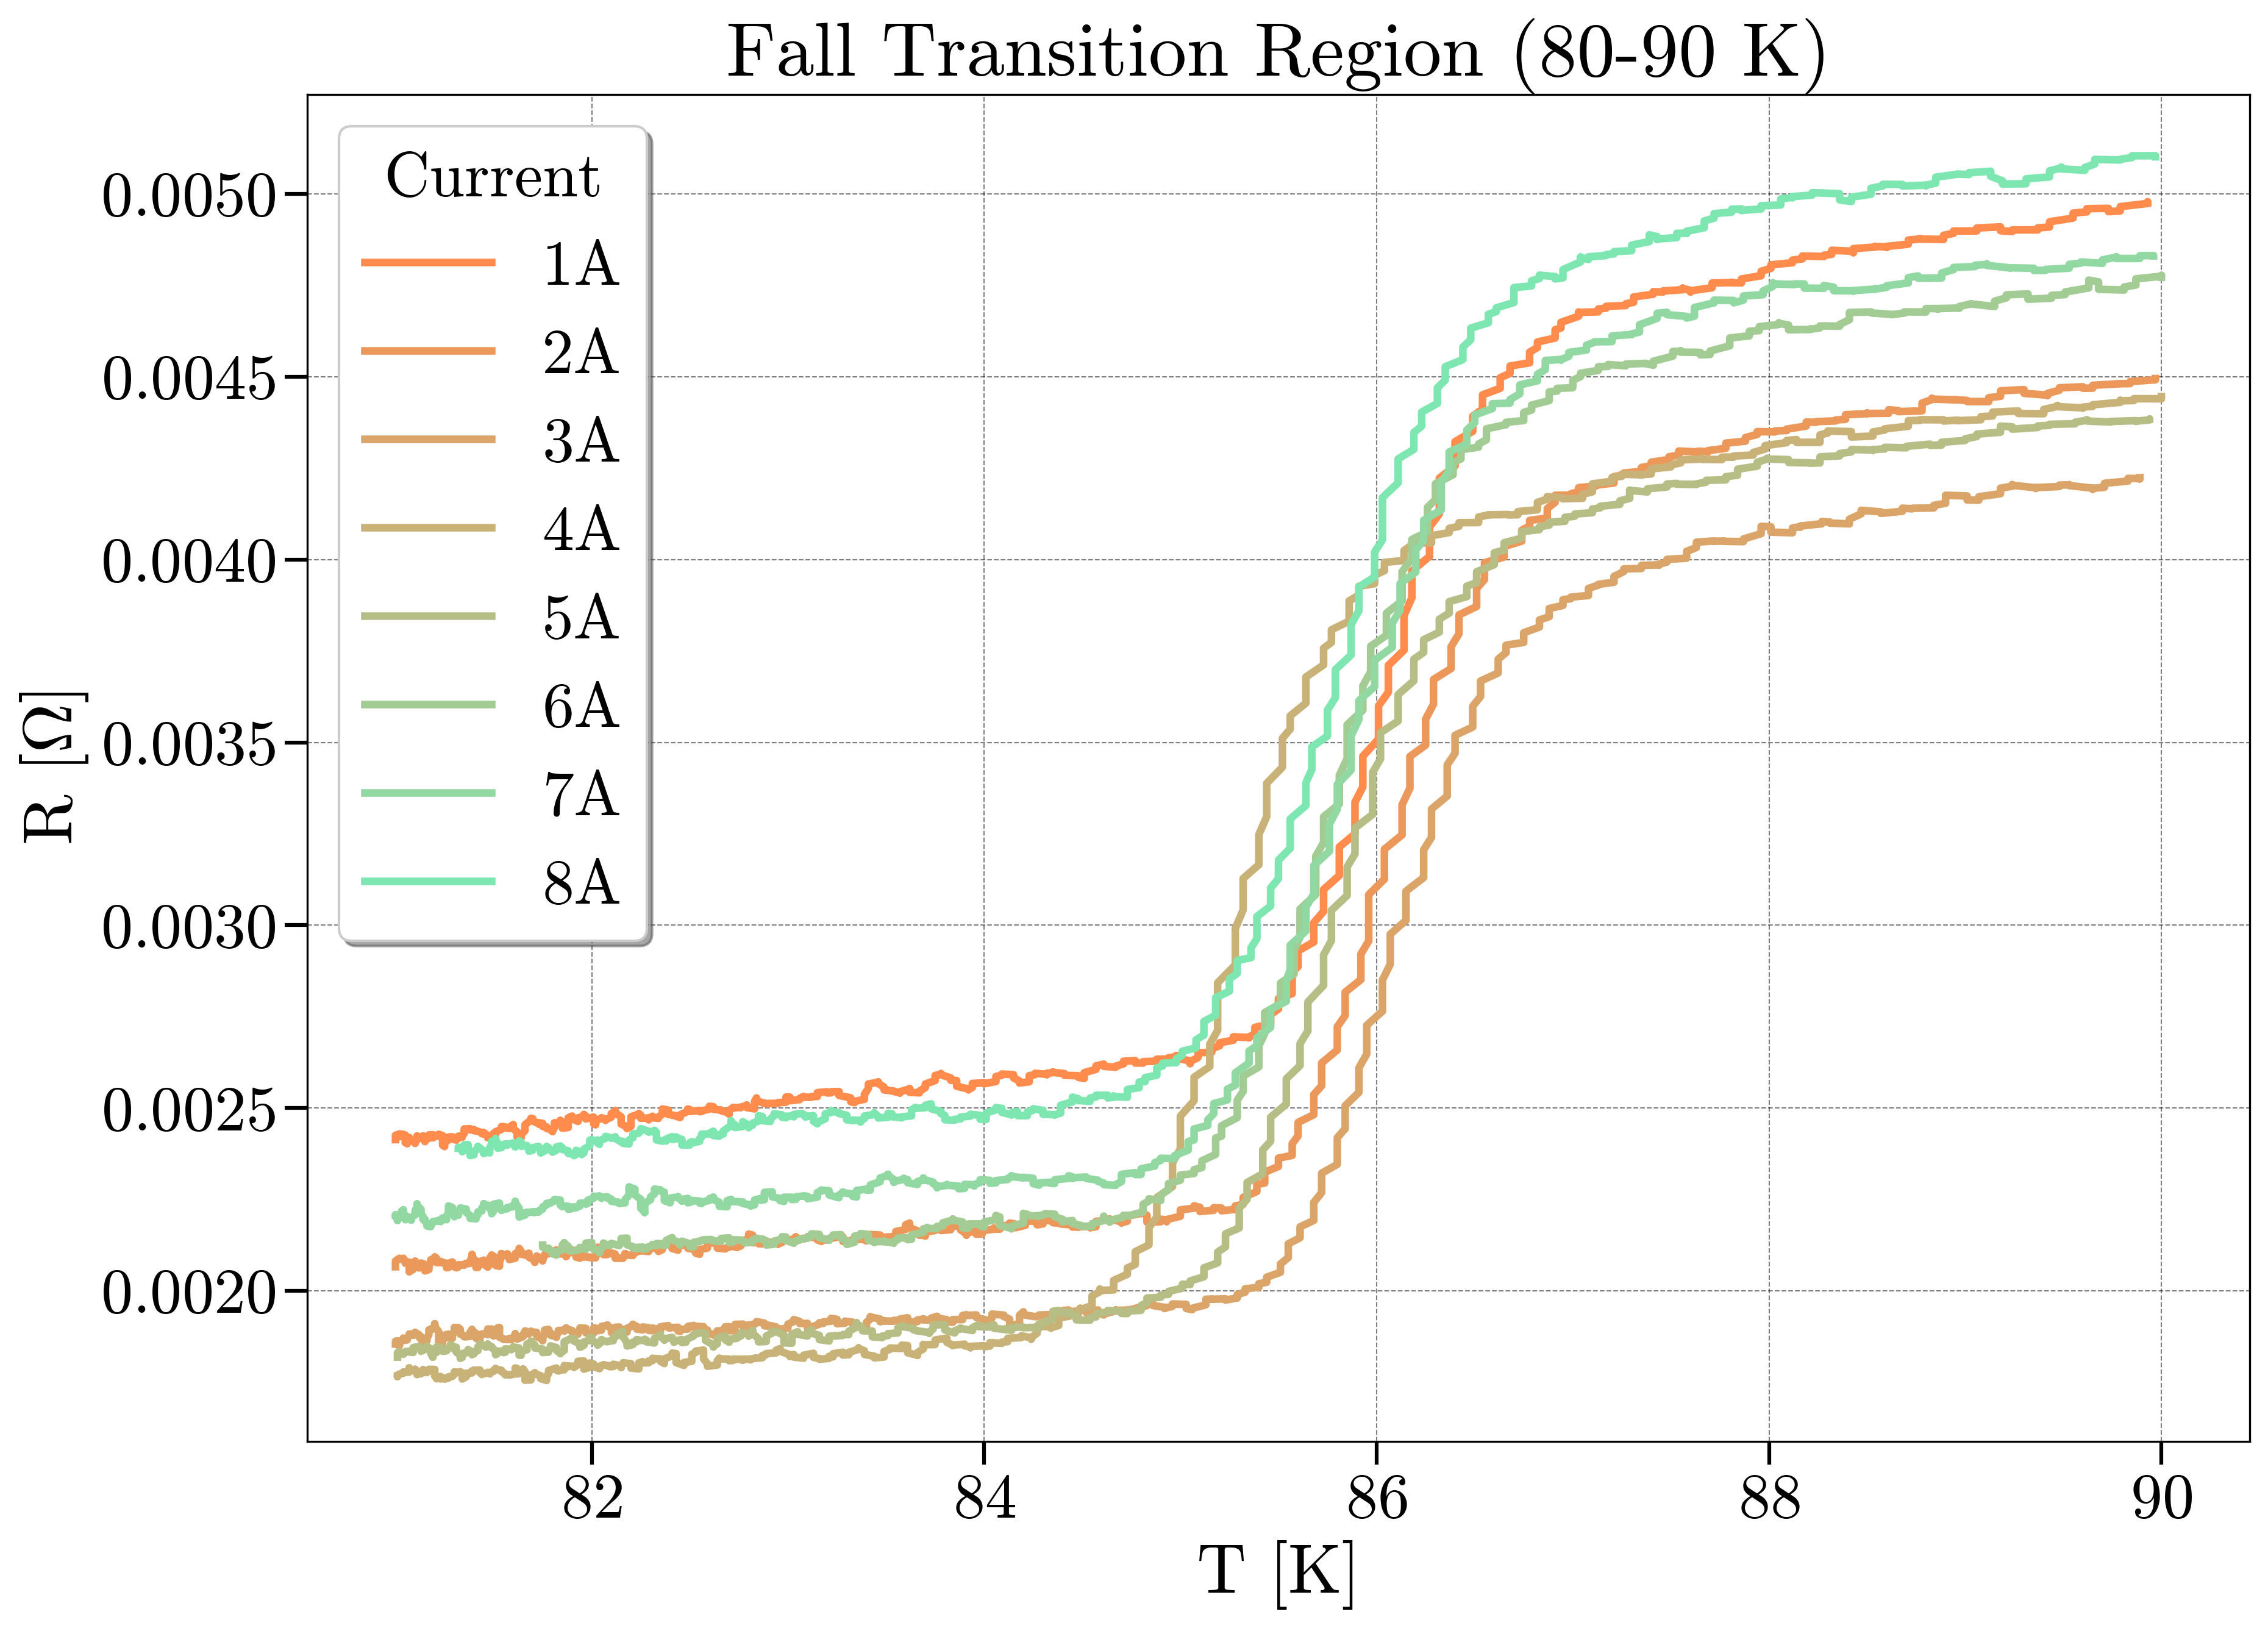

In [5]:
# 绘图：Fall（跃变区）
plt.figure()
for current, df in fall_focus_data.items():
    if current == 0:
        continue
    plt.plot(df['T(K)'].values, df['R(V)'].values/0.01, label=f'{current}A')
plt.xlabel('T [K]')
plt.ylabel('R [$\Omega$]')
plt.title('Fall Transition Region (80-90 K)')
plt.legend(title='Current')
plt.tight_layout()
plt.show()

In [6]:
# 用于存放跃变区间边界点
rise_transition_bounds = {}
fall_transition_bounds = {}

# 帮助函数：计算 dR/dT 并找阈值边界
def find_transition_region(df, threshold_ratio=0.4):
    T = df['T(K)'].values
    R = savgol_filter(df['R(V)'].values, window_length=51, polyorder=2)
    
    # 去除 T 中重复的点（否则 np.gradient 会报错）
    unique_T, unique_indices = np.unique(T, return_index=True)
    unique_R = R[unique_indices]

    if len(unique_T) < 3:
        return None, None  # 点太少无法求导

    # 一阶导数
    dR_dT = np.gradient(unique_R, unique_T)

    # 归一化导数
    norm_dR_dT = dR_dT / np.max(np.abs(dR_dT))

    # 找出高导数区间（跳变区）
    mask = norm_dR_dT > threshold_ratio

    if not np.any(mask):
        return None, None

    indices = np.where(mask)[0]
    start_T = unique_T[indices[0]]
    end_T = unique_T[indices[-1]]

    return start_T, end_T



In [7]:
for current in range(1, 9):
    rise_df = rise_focus_data[current]
    fall_df = fall_focus_data[current]
    
    rise_start, rise_end = find_transition_region(rise_df)
    fall_start, fall_end = find_transition_region(fall_df)

    rise_transition_bounds[current] = (rise_start, rise_end)
    fall_transition_bounds[current] = (fall_start, fall_end)

# 输出
print("Rise Transition Bounds:")
for current, (start, end) in rise_transition_bounds.items():
    print(f"{current}A: Start = {start:.2f} K, End = {end:.2f} K")

print("\nFall Transition Bounds:")
for current, (start, end) in fall_transition_bounds.items():
    print(f"{current}A: Start = {start:.2f} K, End = {end:.2f} K")


Rise Transition Bounds:
1A: Start = 93.63 K, End = 94.32 K
2A: Start = 93.80 K, End = 94.39 K
3A: Start = 93.71 K, End = 94.42 K
4A: Start = 93.78 K, End = 94.63 K
5A: Start = 93.25 K, End = 94.06 K
6A: Start = 93.28 K, End = 94.20 K
7A: Start = 93.22 K, End = 94.15 K
8A: Start = 93.23 K, End = 94.10 K

Fall Transition Bounds:
1A: Start = 85.50 K, End = 86.54 K
2A: Start = 85.57 K, End = 86.55 K
3A: Start = 85.55 K, End = 86.62 K
4A: Start = 84.84 K, End = 85.77 K
5A: Start = 85.23 K, End = 86.24 K
6A: Start = 85.18 K, End = 86.26 K
7A: Start = 85.54 K, End = 86.24 K
8A: Start = 85.25 K, End = 86.35 K


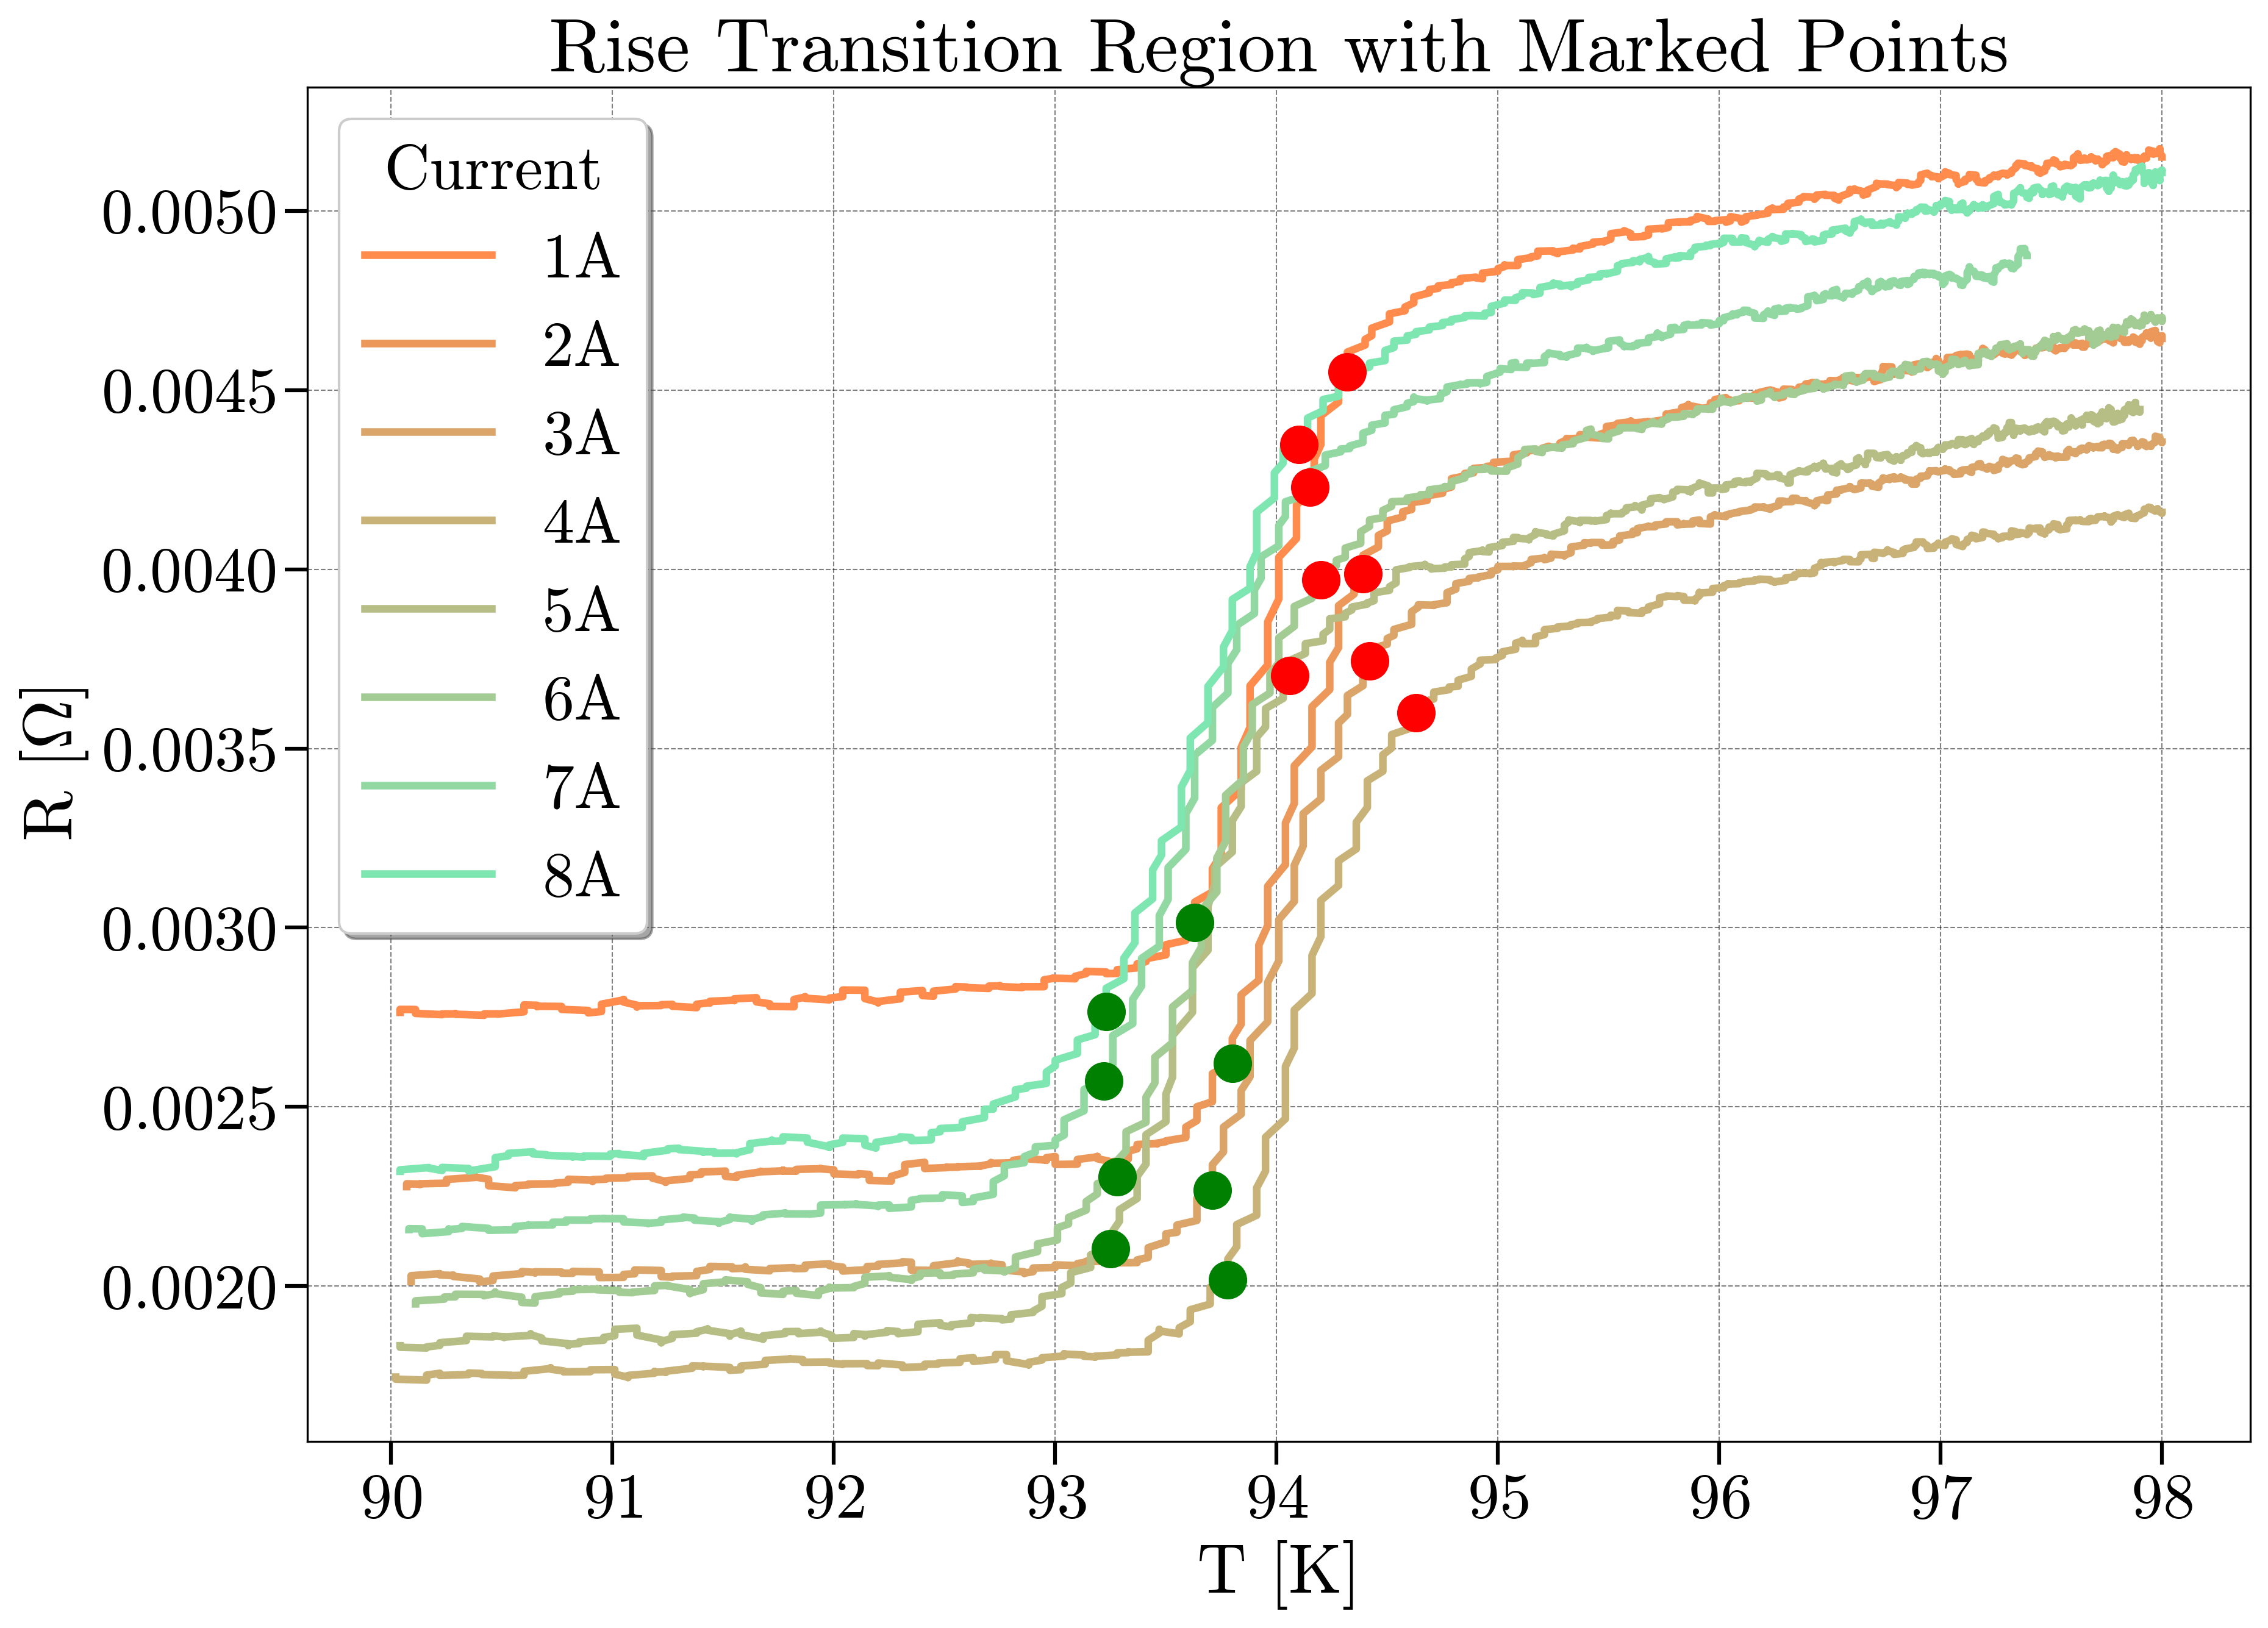

In [8]:
# Rise Data 绘图（带标注）
plt.figure()
for current, df in rise_focus_data.items():
    if current == 0:
        continue
    T = df['T(K)'].values
    R = df['R(V)'].values/0.01
    plt.plot(T, R, label=f'{current}A', zorder=1)

    # 标注跃变起始和结束点
    start_T, end_T = rise_transition_bounds[current]

    # 找到最接近的原始数据点（而非插值）
    start_idx = np.argmin(np.abs(T - start_T))
    end_idx = np.argmin(np.abs(T - end_T))

    plt.scatter(T[start_idx], R[start_idx], s=200, color='green', zorder=2)  # green dot: start
    plt.scatter(T[end_idx], R[end_idx], s=200, color='red', zorder=2)      # red dot: end

plt.xlabel('T [K]')
plt.ylabel('R [$\Omega$]')
plt.title('Rise Transition Region with Marked Points')
plt.legend(title='Current')
plt.tight_layout()
plt.show()



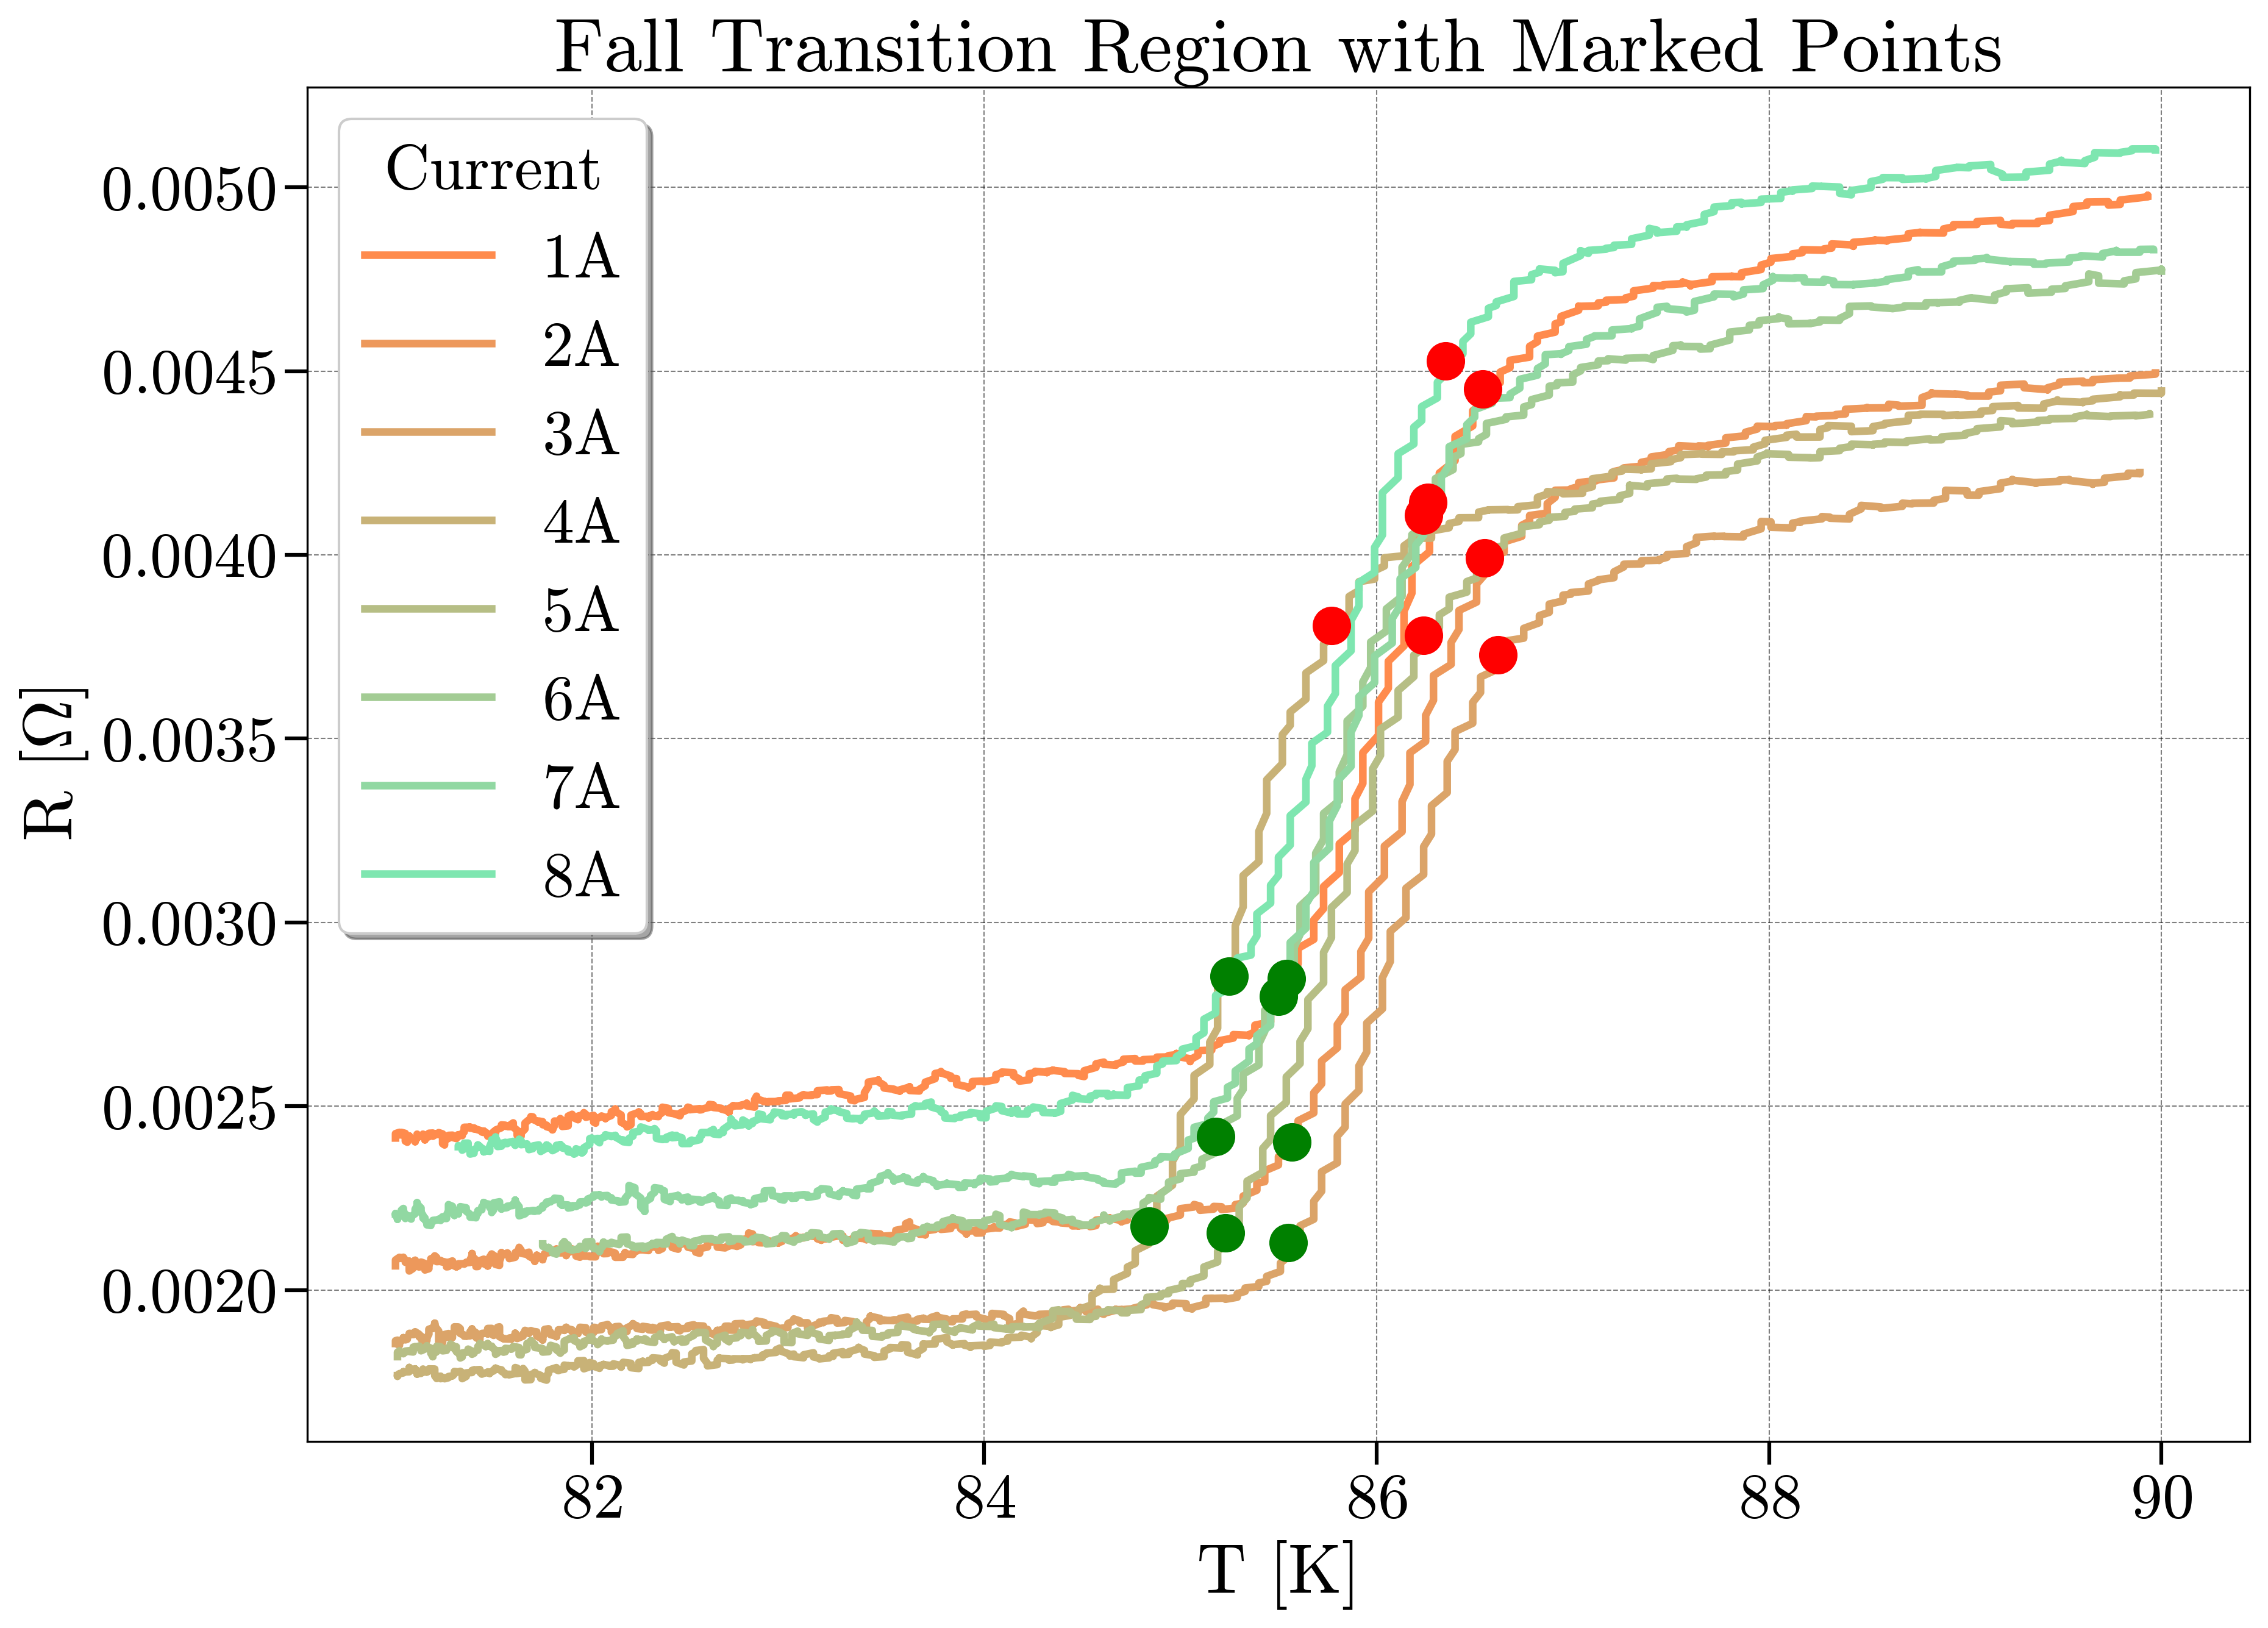

In [9]:
# Fall Data 绘图（带标注）
plt.figure()
for current, df in fall_focus_data.items():
    if current == 0:
        continue
    T = df['T(K)'].values
    R = df['R(V)'].values/0.01
    plt.plot(T, R, label=f'{current}A', zorder=1)

    # 标注跃变起始和结束点
    start_T, end_T = fall_transition_bounds[current]
    start_idx = np.argmin(np.abs(T - start_T))
    end_idx = np.argmin(np.abs(T - end_T))

    plt.scatter(T[start_idx], R[start_idx], s=200, color='green', zorder=2)  # green dot: start
    plt.scatter(T[end_idx], R[end_idx], s=200, color='red', zorder=2)      # red dot: end

plt.xlabel('T [K]')
plt.ylabel('R [$\Omega$]')
plt.title('Fall Transition Region with Marked Points')
plt.legend(title='Current')
plt.tight_layout()
plt.show()
